# Custom CNN architecture

Processing calc patients: 100%|█████████████████████████████████████████████████████| 114/114 [00:00<00:00, 153.64it/s]



calc:
  Train patients: 527
  Val patients:   112
  Test patients:  114
  Total patients: 753
  Overlaps: train-val=0, train-test=0, val-test=0
  Image counts -> Train: 1352, Val: 254, Test: 266


Processing mass patients: 100%|█████████████████████████████████████████████████████| 135/135 [00:00<00:00, 213.98it/s]



mass:
  Train patients: 624
  Val patients:   133
  Test patients:  135
  Total patients: 892
  Overlaps: train-val=0, train-test=0, val-test=0
  Image counts -> Train: 1199, Val: 255, Test: 242
Non-CLAHE shapes -> X_train: (2551, 224, 224, 1), X_val: (509, 224, 224, 1), X_test: (508, 224, 224, 1)
CLAHE shapes -> X_train: (2551, 224, 224, 1), X_val: (509, 224, 224, 1), X_test: (508, 224, 224, 1)
clahe
train


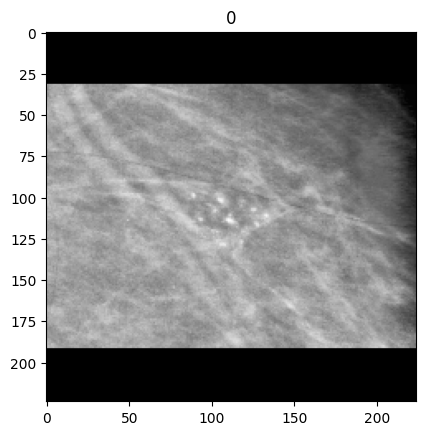

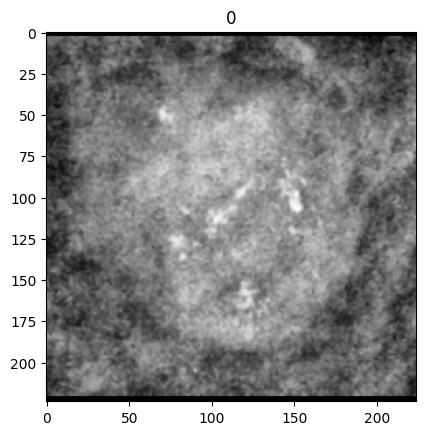

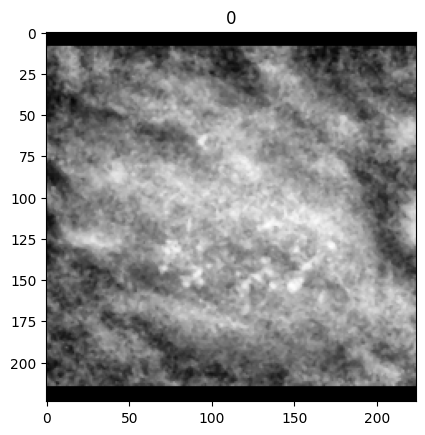

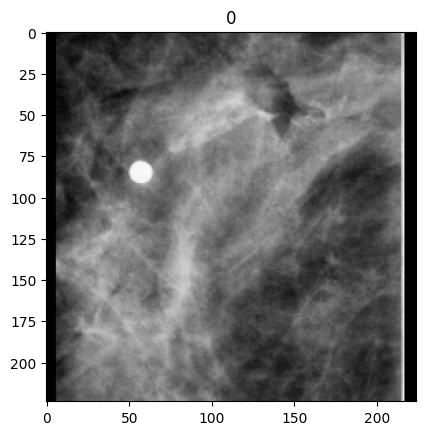

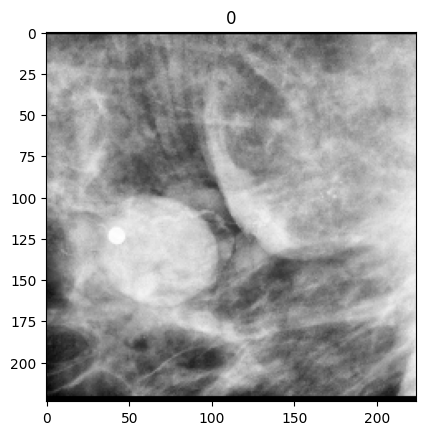

val


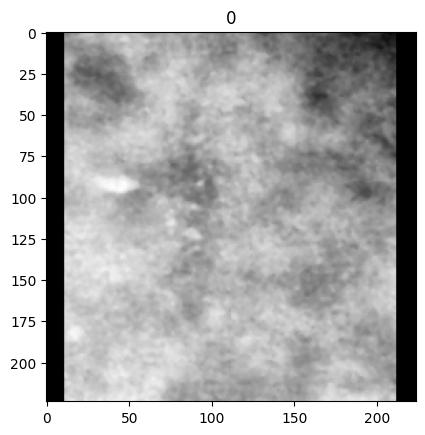

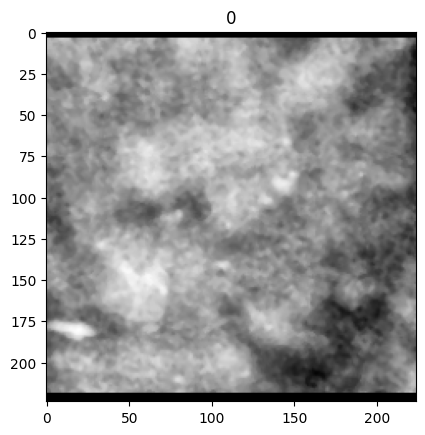

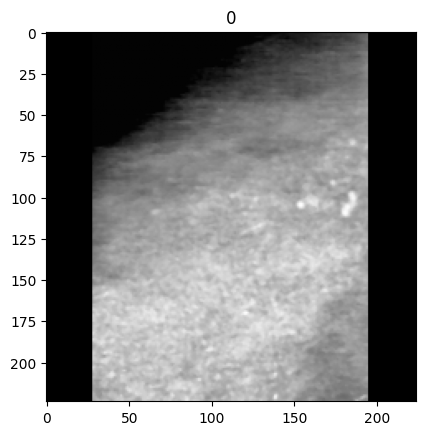

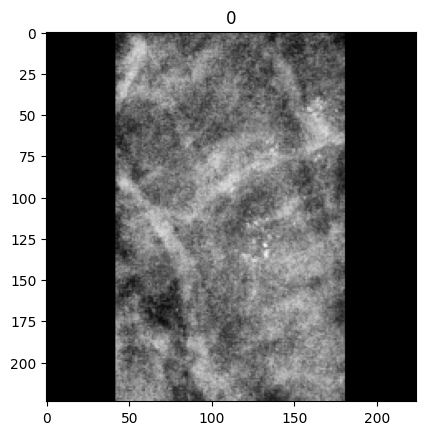

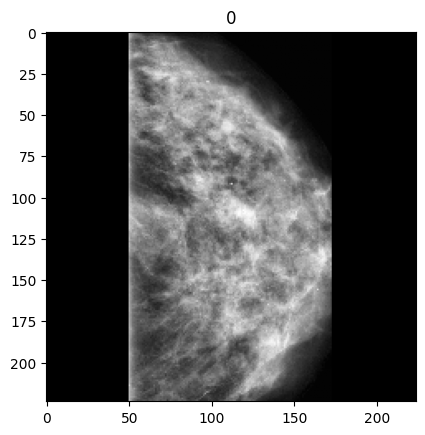

test


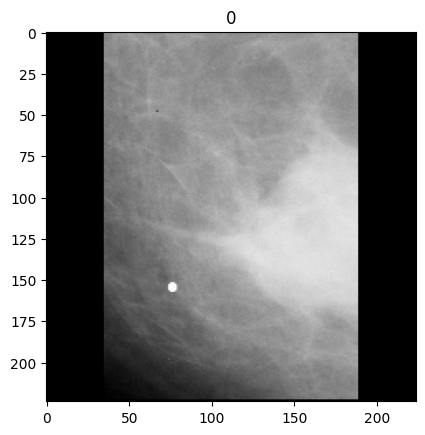

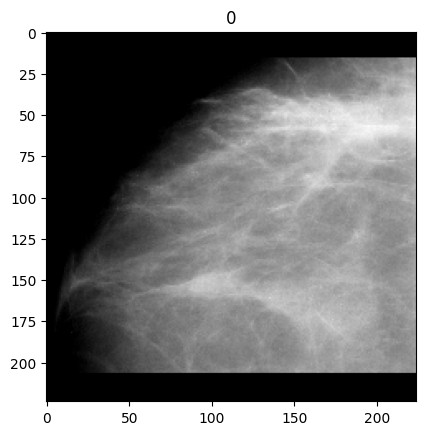

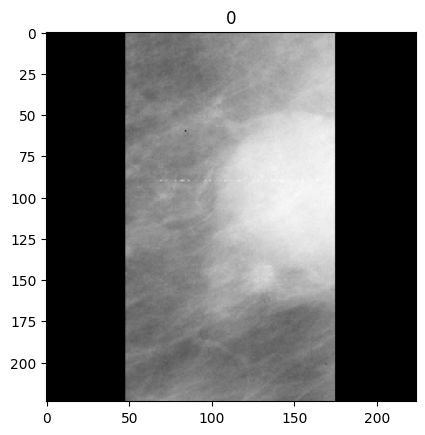

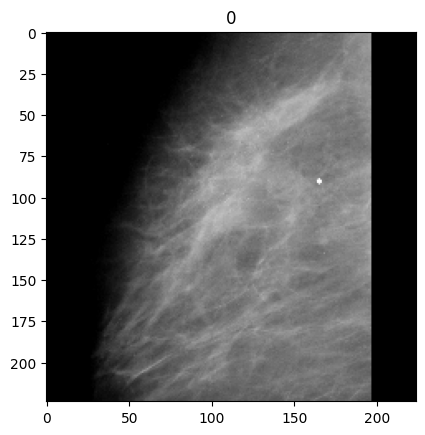

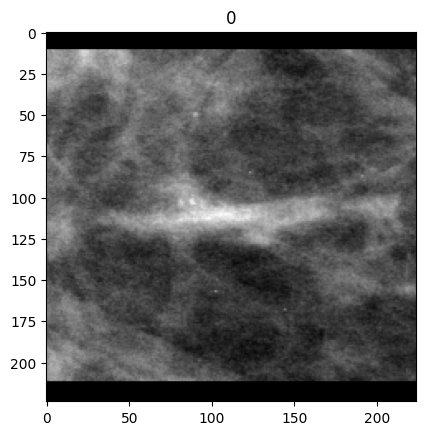

non clahe
train


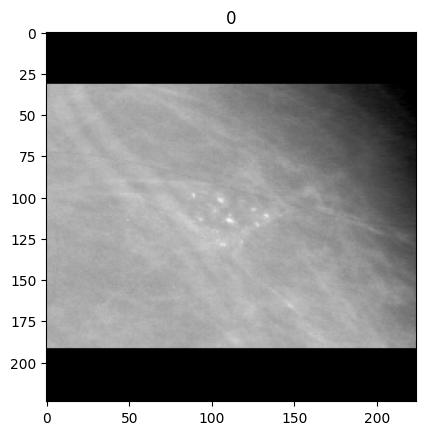

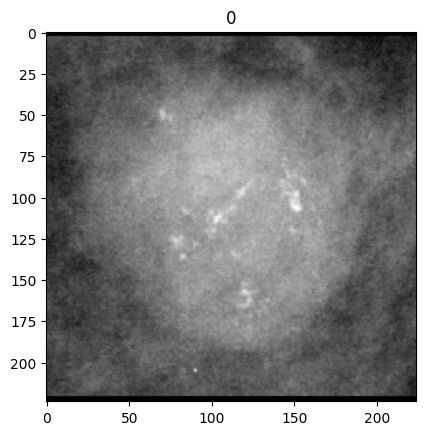

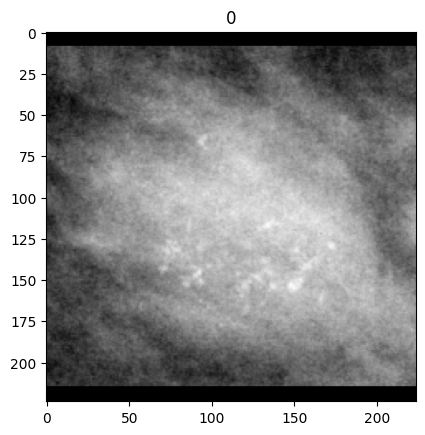

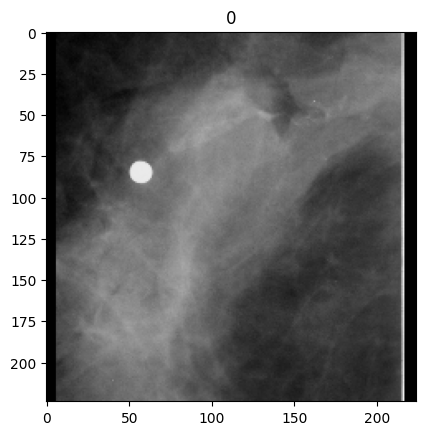

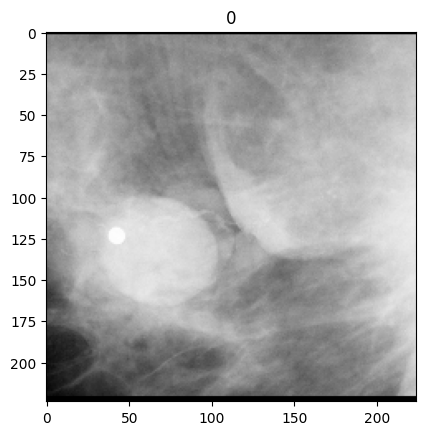

val


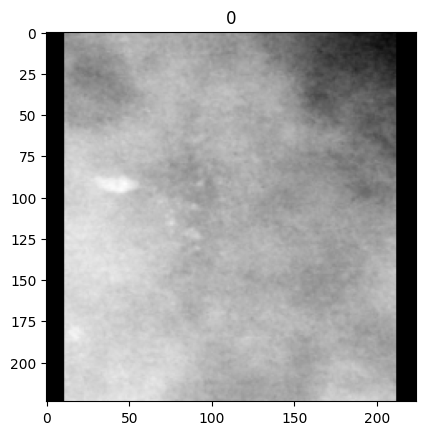

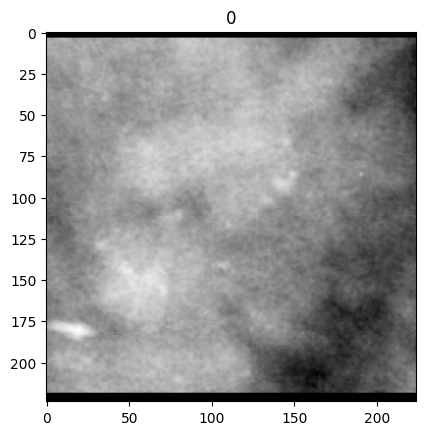

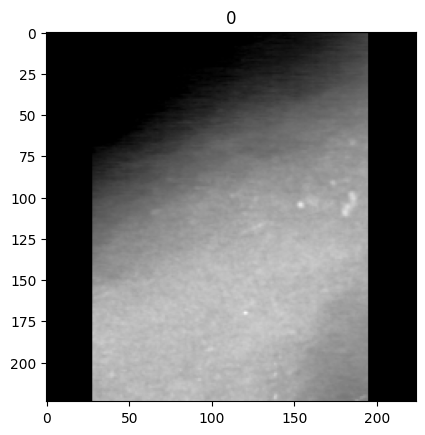

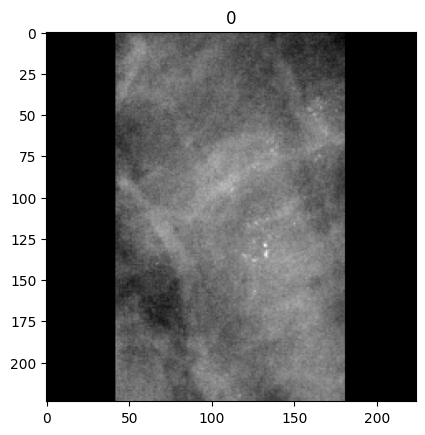

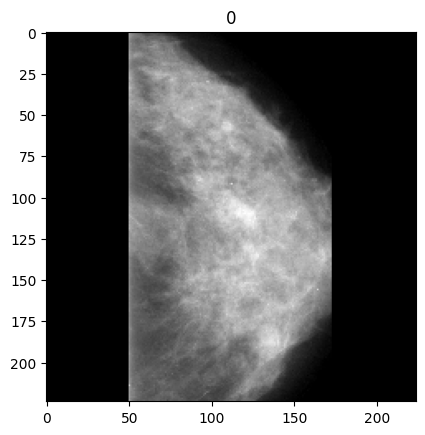

test


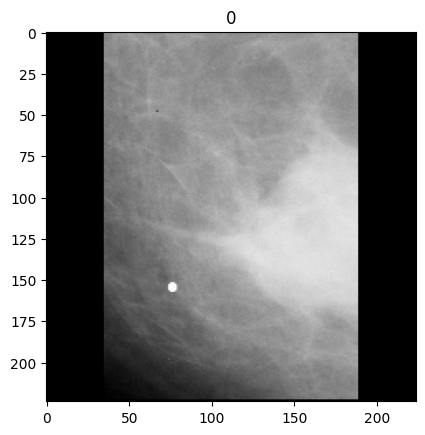

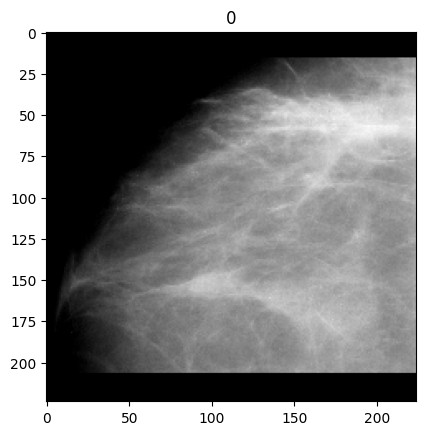

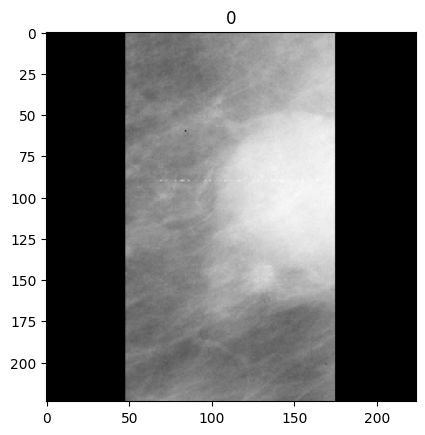

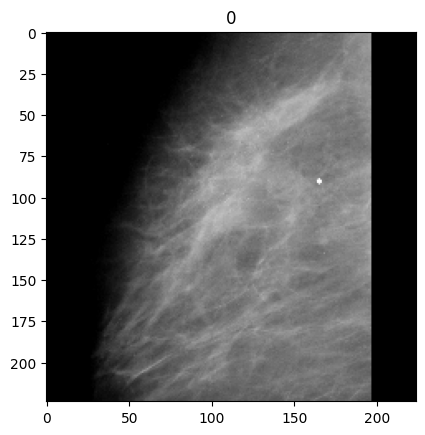

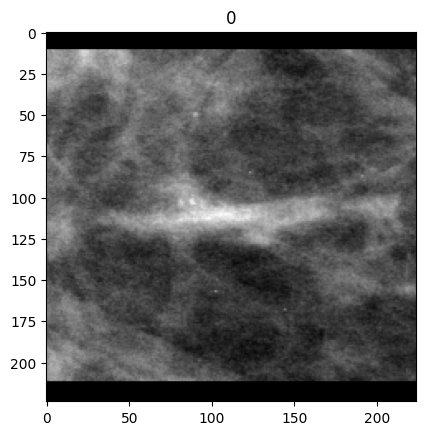

In [1]:
# Run the previous notebook to load all its classes and functions
%run cbis_ddsm_create_ROI_dataset_classification.ipynb

### Normalize Data
This step is important because:
- we have features which are in a wide range (each pixels ranges from 0 to 255)
- we have to make them matter the same to the ML model
- prevent numerical instability
- normal distribution assumption

In [2]:
print(f"Non-CLAHE shapes -> X_train_non: {X_train_non_clahe.shape}, X_val_non: {X_val_non_clahe.shape}, X_test_non: {X_test_non_clahe.shape}")
print(f"CLAHE shapes -> X_train: {X_train_clahe.shape}, X_val: {X_val_clahe.shape}, X_test: {X_test_clahe.shape}")

Non-CLAHE shapes -> X_train_non: (2551, 224, 224, 1), X_val_non: (509, 224, 224, 1), X_test_non: (508, 224, 224, 1)
CLAHE shapes -> X_train: (2551, 224, 224, 1), X_val: (509, 224, 224, 1), X_test: (508, 224, 224, 1)


In [3]:
X_train_non_clahe = X_train_non_clahe.astype('float32') / 255.0
X_val_non_clahe   = X_val_non_clahe.astype('float32') / 255.0
X_test_non_clahe  = X_test_non_clahe.astype('float32') / 255.0

print(f"Final shapes AFTER NORMALIZATION -> X_train_non_clahe: {X_train_non_clahe.shape}, X_val_non: {X_val_non_clahe.shape}, X_test_non: {X_test_non_clahe.shape}")


X_train_clahe = X_train_clahe.astype('float32') / 255.0
X_val_clahe   = X_val_clahe.astype('float32') / 255.0
X_test_clahe  = X_test_clahe.astype('float32') / 255.0

print(f"Final shapes AFTER NORMALIZATION -> X_train: {X_train_clahe.shape}, X_val: {X_val_clahe.shape}, X_test: {X_test_clahe.shape}")

Final shapes AFTER NORMALIZATION -> X_train_non_clahe: (2551, 224, 224, 1), X_val_non: (509, 224, 224, 1), X_test_non: (508, 224, 224, 1)
Final shapes AFTER NORMALIZATION -> X_train: (2551, 224, 224, 1), X_val: (509, 224, 224, 1), X_test: (508, 224, 224, 1)


## CNN training

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU, BatchNormalization, Conv2D, MaxPooling2D, Flatten,  Dropout, Activation
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import seaborn as sns
import time

## Explaining some concepts that we will use later

### CNNs
- specialized NNs designed for grid-like data
- automatically learn spacial hierarchies of features through convolution operations
- highly effective in tasks involving visual perception

### Convolutional layer
**Convolution** is a mathematical operation where a small filter (kernel) is systematically applied across an input (such as an image) to produce a feature map that captures important local patterns like edges, textures, or more complex structures.

- **number of filters** = how many different kernels does the layer apply? So we basically get **number of filters** different feature maps.
- As we go on through the layers of the model, we may need more and more different kernels to try, because we have more intricate patterns in the images.

- **kernel_size** = what is the size of the filter/kernels, helping us to detect edges like shapes, edges etc.

- **activation** = the activation function used

### Pooling layers

A pooling layer reduces the spatial dimentions(width and height) of a feature map by summarizing regions of th input, helping to decrease computation, control overfitting, and make the network more robust to small translations

Purpose:

- downsampling: reduces the size of feature maps;
- feature preservation: keeps the most important information
- translation invariance: small changes in input data do not change the pooled output much

### Max Pooling

Helps us detect the strongest activation, e.g. what feature is the most present. This way, we can detect more proeminent patterns and also improve computations.

### Fully Connected Layers

Learn from the high-level features extracted by convolutional and pooling layers

- **dropout** - during training, turns off a percent of neurons in the Dense layer, to prevent overfitting.

### ReLU Activation
- keeps patterns of the data, also getting rid of negative values
- neurons stuck with negative inputs stop updating (gradient = 0)
- most popular in modern NNs

### LeakyReLU 
- allows a small gradient when x < 0 → avoids dying ReLU.

### Batch size
- how many training samples the network processes before updating its weights during training. It influences both the model's performance and the computational efficiency.
- some mostly used values are 32, 64, 128 ...
- I chose 32 because it puts in balance the computational resources needed and the efficiency of the model



### Adam Optimizer

Adam (short for **Adaptive Moment Estimation**) is one of the most popular and effective optimization algorithms used to train deep learning models. Adam adapts the learning rate for each parameter individually using **first** and **second moments** of the gradients:

- The **first moment** is the **mean** of the gradient (like momentum).
- The **second moment** is the **uncentered variance** of the gradient.

This helps Adam:
- Converge faster
- Handle sparse gradients
  

# Custom CNNs (initial trials)

### A) Non-clahe

In [5]:
# Hyperparameter options

activations = [
    ("relu", "relu"),
    ("leakyrelu", LeakyReLU(negative_slope=0.01))
]
conv_base_filters =[32, 64]


histories_n = []


for conv_base_filter in conv_base_filters:
    for activation_name, activation_fn in activations:
            print(
                f"Training model with: "
                f"activation={activation_name}, "
                f"conv_base_filter={conv_base_filter}"
            )
        
            #Apply early stopping to save time & avoid overfitting
            # Early stopping
            early_stop = EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss', verbose=1)


            # Model definition
            model = Sequential([
                Input(shape=(224, 224, 1)),
                Conv2D(conv_base_filter, kernel_size=(3,3), activation=activation_fn),
                MaxPooling2D(pool_size=(2, 2)),

                Conv2D(conv_base_filter*2, kernel_size=(3,3), activation=activation_fn),
                MaxPooling2D(pool_size=(2, 2)),

                Conv2D(conv_base_filter*4, kernel_size=(3,3), activation=activation_fn),
                MaxPooling2D(pool_size=(2, 2)),

                Flatten(),
                Dense(128, activation=activation_fn),
                Dropout(0.5),
                Dense(2, activation='softmax')
            ])

            # Compile
            model.compile(
                optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

            # Train
            history = model.fit(
                X_train_non_clahe, y_train_non_clahe,
                validation_data=(X_val_non_clahe, y_val_non_clahe),
                epochs=30,
                batch_size=32,
                callbacks=[early_stop]
            )

            # Save
            label = (
                f"conv_base_filter={conv_base_filter}, "
                f"activation={activation_name} "
            )
            histories_n.append((label, history))


Training model with: activation=relu, conv_base_filter=32
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 557ms/step - accuracy: 0.5860 - loss: 0.6973 - val_accuracy: 0.5678 - val_loss: 0.6734
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 557ms/step - accuracy: 0.6252 - loss: 0.6496 - val_accuracy: 0.4990 - val_loss: 0.6707
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 539ms/step - accuracy: 0.7279 - loss: 0.5419 - val_accuracy: 0.7603 - val_loss: 0.5300
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 558ms/step - accuracy: 0.7856 - loss: 0.4724 - val_accuracy: 0.7564 - val_loss: 0.5085
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 563ms/step - accuracy: 0.8071 - loss: 0.4353 - val_accuracy: 0.7367 - val_loss: 0.5265
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 568ms/step - accuracy: 0.8193 - loss: 0.4006 - val_accuracy: 0.7800 - val_loss: 0.4556
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 48s 598ms/step - accuracy: 0.8358 - loss: 0.3987 - val_accuracy: 0.7800 - val_loss: 0.4335
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 4

### B) CLAHE

In [6]:
# Hyperparameter options

activations = [
    ("relu", "relu"),
    ("leakyrelu", LeakyReLU(negative_slope=0.01))
]
conv_base_filters =[32, 64]


histories = []


for conv_base_filter in conv_base_filters:
    for activation_name, activation_fn in activations:
            print(
                f"Training model with: "
                f"activation={activation_name}, "
                f"conv_base_filter={conv_base_filter}"
            )
        
            #Apply early stopping to save time & avoid overfitting
            # Early stopping
            early_stop = EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss', verbose=1)


            # Model definition
            model = Sequential([
                Input(shape=(224, 224, 1)),
                Conv2D(conv_base_filter, kernel_size=(3,3), activation=activation_fn),
                MaxPooling2D(pool_size=(2, 2)),

                Conv2D(conv_base_filter*2, kernel_size=(3,3), activation=activation_fn),
                MaxPooling2D(pool_size=(2, 2)),

                Conv2D(conv_base_filter*4, kernel_size=(3,3), activation=activation_fn),
                MaxPooling2D(pool_size=(2, 2)),

                Flatten(),
                Dense(128, activation=activation_fn),
                Dropout(0.5),
                Dense(2, activation='softmax')
            ])

            # Compile
            model.compile(
                optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

            # Train
            history = model.fit(
                X_train_clahe, y_train_clahe,
                validation_data=(X_val_clahe, y_val_clahe),
                epochs=30,
                batch_size=32,
                callbacks=[early_stop]
            )

            # Save
            label = (
                f"conv_base_filter={conv_base_filter}, "
                f"activation={activation_name} "
            )
            histories.append((label, history))


Training model with: activation=relu, conv_base_filter=32
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 530ms/step - accuracy: 0.6170 - loss: 0.6712 - val_accuracy: 0.5246 - val_loss: 0.7500
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 526ms/step - accuracy: 0.7554 - loss: 0.5068 - val_accuracy: 0.7289 - val_loss: 0.5377
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 530ms/step - accuracy: 0.8126 - loss: 0.4238 - val_accuracy: 0.7819 - val_loss: 0.4512
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 541ms/step - accuracy: 0.8275 - loss: 0.3944 - val_accuracy: 0.7800 - val_loss: 0.4273
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 526ms/step - accuracy: 0.8354 - loss: 0.3658 - val_accuracy: 0.8114 - val_loss: 0.4351
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 533ms/step - accuracy: 0.8597 - loss: 0.3390 - val_accuracy: 0.8153 - val_loss: 0.4128
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 539ms/step - accuracy: 0.8659 - loss: 0.3160 - val_accuracy: 0.8251 - val_loss: 0.4209
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 4

After running multiple experiments (see the documents attached on github), the architecture with initial 64 filters and LeakyRelu activation function was selected for fine-tuning. The choice balances model complexity with performance in a practical manner.


In [24]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule_1)

# Compile 
model_final.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
 
# Train
history = model_final.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.3549 - loss: 1.1847 - val_accuracy: 0.5641 - val_loss: 1.0445
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.4005 - loss: 1.0835 - val_accuracy: 0.5983 - val_loss: 0.9883
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5017 - loss: 1.0069 - val_accuracy: 0.6068 - val_loss: 0.8393
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5899 - loss: 0.8756 - val_accuracy: 0.6838 - val_loss: 0.7642
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.6689 - loss: 0.7445 - val_accuracy: 0.6838 - val_loss: 0.7679
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8015 - loss: 0.5002 - val_accuracy: 0.7094 - val_loss: 0.7470
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8720 - loss: 0.3526 - val_accuracy: 0.7094 - val_loss: 0.7082
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9141 - loss: 0.2455 - val_accuracy: 0.7094 - val_loss:

In [25]:
# Early stopping
early_stop = EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss', verbose=1)

model_final = Sequential([
        Input(shape=(224, 224, 1)),
        Conv2D(64, kernel_size=(5,5), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(128, kernel_size=(3,3), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(256, kernel_size=(3,3), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Flatten(),
        Dense(128, activation=(LeakyReLU(negative_slope=0.01))),
        Dropout(0.7),
        Dense(3, activation='softmax')
        ])

In [26]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule_2)

# Compile
model_final.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
 
# Train
history = model_final.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.3601 - loss: 1.2212 - val_accuracy: 0.5556 - val_loss: 1.0730
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.4619 - loss: 1.0333 - val_accuracy: 0.4872 - val_loss: 0.9565
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.5421 - loss: 0.9341 - val_accuracy: 0.5556 - val_loss: 0.8842
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6638 - loss: 0.7708 - val_accuracy: 0.6667 - val_loss: 0.7448
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7645 - loss: 0.5982 - val_accuracy: 0.7094 - val_loss: 0.8014
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8527 - loss: 0.3826 - val_accuracy: 0.6325 - val_loss: 0.7200
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9044 - loss: 0.2570 - val_accuracy: 0.6923 - val_loss: 0.7959
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9369 - loss: 0.1807 - val_accuracy: 0.7265 - val_loss:

In [27]:
# Early stopping
early_stop = EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss', verbose=1)

model_final = Sequential([
        Input(shape=(224, 224, 1)),
        Conv2D(64, kernel_size=(5,5), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(128, kernel_size=(3,3), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(256, kernel_size=(3,3), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Flatten(),
        Dense(128, activation=(LeakyReLU(negative_slope=0.01))),
        Dropout(0.7),
        Dense(3, activation='softmax')
        ])

In [28]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule_3)

# Compile
model_final.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
 
# Train
history = model_final.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.3544 - loss: 1.1239 - val_accuracy: 0.5128 - val_loss: 1.0665
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5228 - loss: 0.9835 - val_accuracy: 0.6410 - val_loss: 0.9246
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6638 - loss: 0.7708 - val_accuracy: 0.6838 - val_loss: 0.8120
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.7850 - loss: 0.5575 - val_accuracy: 0.6496 - val_loss: 0.6975
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8641 - loss: 0.3731 - val_accuracy: 0.6239 - val_loss: 0.8539
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9078 - loss: 0.2459 - val_accuracy: 0.7094 - val_loss: 0.7547
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9397 - loss: 0.1813 - val_accuracy: 0.7436 - val_loss: 0.7360
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9562 - loss: 0.1315 - val_accuracy: 0.7009 - val_loss:

In [8]:
# Early stopping
early_stop = EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss', verbose=1)

model_final = Sequential([
        Input(shape=(224, 224, 1)),
        Conv2D(64, kernel_size=(5,5), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(128, kernel_size=(3,3), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Conv2D(256, kernel_size=(3,3), activation=(LeakyReLU(negative_slope=0.01))),
        MaxPooling2D(pool_size=(2, 2)),
    
        Flatten(),
        Dense(128, activation=(LeakyReLU(negative_slope=0.01))),
        Dropout(0.7),
        Dense(3, activation='softmax')
        ])

In [9]:
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule_4)

# Compile
model_final.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
 
# Train
history = model_final.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.3504 - loss: 1.3273 - val_accuracy: 0.5556 - val_loss: 1.0411
Epoch 2/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.3709 - loss: 1.0917 - val_accuracy: 0.5983 - val_loss: 1.0143
Epoch 3/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.4784 - loss: 1.0229 - val_accuracy: 0.5641 - val_loss: 0.9324
Epoch 4/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.5176 - loss: 1.0002 - val_accuracy: 0.4957 - val_loss: 0.9944
Epoch 5/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.5620 - loss: 0.9123 - val_accuracy: 0.6068 - val_loss: 0.8251
Epoch 6/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6013 - loss: 0.8413 - val_accuracy: 0.6410 - val_loss: 0.7810
Epoch 7/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.7008 - loss: 0.6888 - val_accuracy: 0.6752 - val_loss: 0.7183
Epoch 8/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7850 - loss: 0.5038 - val_accuracy: 0.6923 - val_loss:

## Final choices

We have 4 choices: 

    - 1. simple model_final 
    
    - 2. model_final with aggressive decay
    
    - 3. model_final with lr_schedule_1 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=30 * len(X_train_aug),  # for 30 epochs
    alpha=1e-5)

    - 4. model_final with lr_schedule_4 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=40 * len(X_train_aug),  # longer decay
    alpha=1e-5
)

Although Model 2 had slightly better validation accuracy and lower loss, all 4 models reached comparable performance levels. Therefore, further evaluation using metrics such as precision, recall, F1-score, and confusion matrix was conducted to ensure fairness and robustness, especially considering the clinical importance of avoiding false negatives. -> see the next notebook